# Activation-pattern contrasts

Each ligand carries a three-bit pattern over [class1, common, class2]. Grouping those
patterns gives the sets contrasted here:

- **class1 side** — `100` + `110`, bound by the class 1 ancestor but not class 2
- **class2 side** — `011`, bound by class 2 and the common ancestor but not class 1
- **shared** — `111`, bound by all three
- **common only** — `010`, held by the common ancestor and dropped by both

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


In [2]:
chem = descriptors(anc.all_smiles).merge(functional_groups(anc.all_smiles), on="SMILES")
FG_COLS = list(FG_SMARTS)
chem.head()

,SMILES,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(CCCC(=O)O)CCCBr,2.8065,37.30,223.110,1,1,1,0,0,0,0,0,0,0,0,0,0,0
1,C(CCCCC(=O)O)CCCCBr,3.5867,37.30,251.164,1,1,1,0,0,0,0,0,0,0,0,0,0,0
2,C(CCCCCBr)CCCCC(=O)O,3.9768,37.30,265.191,1,1,1,0,0,0,0,0,0,0,0,0,0,0
3,C(CCCCCC(=O)O)CCCCCBr,4.3669,37.30,279.218,1,1,1,0,0,0,0,0,0,0,0,0,0,0
4,C/C=C/C(=O)C1=C(C=CCC1(C)C)C,3.4342,17.07,190.286,0,1,0,0,0,1,0,0,0,0,0,0,0,1


## Group sizes

In [3]:
groups = {k: v for k, v in anc.code_sets.items()}
sizes = pd.Series({k: len(v) for k, v in groups.items()})
print(sizes.to_string())
save_table(sizes.rename("n_ligands").reset_index().rename(columns={"index": "group"}),
           "02_group_sizes")

class1_side    19
class2_side     6
shared          2
common_only    12


## The five presence patterns

Each ligand is a column; the three rows are the ancestral nodes. Columns are grouped by
pattern, and the strip above marks which group each column belongs to.

patterns kept for testing (n >= 5): {'100': 17, '011': 5, '010': 12}


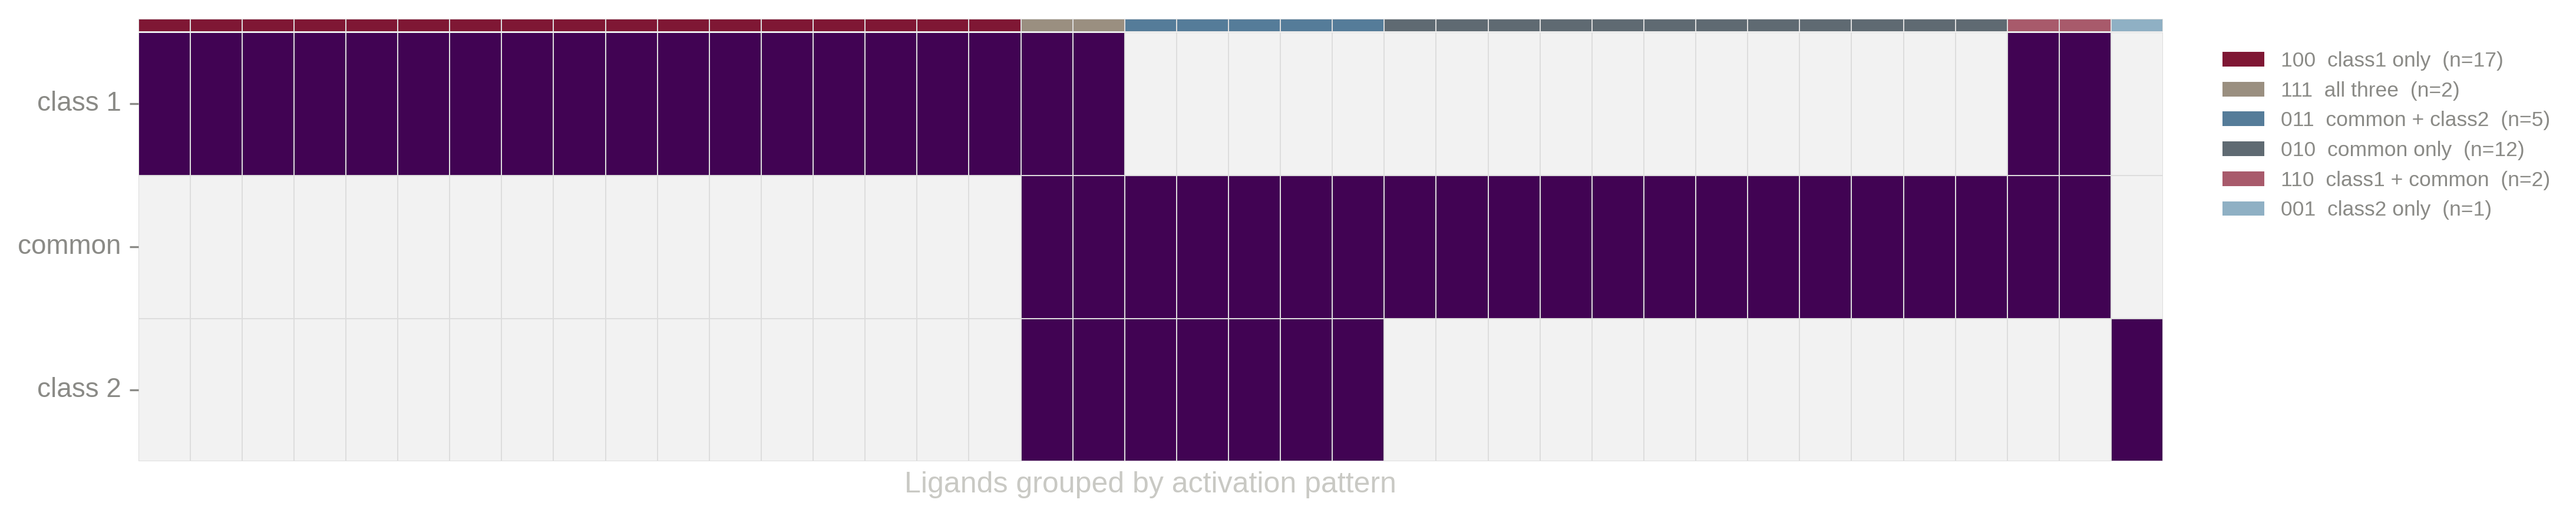

In [4]:
PAT_COL = {"100": CLASS1_COL, "110": "#a85a6b", "111": "#9a8f80",
           "010": COMMON_COL, "011": CLASS2_COL, "001": "#8fb0c4", "101": "#c9c9c4"}
KEEP = [p for p in PATTERN_ORDER if len(anc.pattern_sets[p]) >= 5]
print("patterns kept for testing (n >= 5):", {p: len(anc.pattern_sets[p]) for p in KEEP})

X = anc.node_presence.set_index("SMILES")[
    ["class1_ancestor", "common_ancestor", "class2_ancestor"]].T
X.index = ["class 1", "common", "class 2"]
X = X.loc[:, X.sum(axis=0) > 0]

patterns = X.apply(lambda col: "".join(col.astype(int).astype(str).values), axis=0).astype(str)
col_order = sorted(X.columns, key=lambda c: (PATTERN_ORDER.index(patterns.loc[c]), c))
Xo = X[col_order]
col_colors = patterns.loc[col_order].map(PAT_COL).tolist()
present = [p for p in PATTERN_ORDER if len(anc.pattern_sets[p])]

cg = sns.clustermap(
    Xo,
    row_cluster=False,
    col_cluster=False,
    cmap=ListedColormap(["#f2f2f2", "#410353"]),
    vmin=0, vmax=1,
    cbar_pos=None,
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors,
    linewidths=0.4, linecolor="#dddddd",
    figsize=(12, 3),
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=(0.03, 0.03),
)

ax = cg.ax_heatmap
ax.set_yticklabels(ax.get_ymajorticklabels(), rotation=0, fontsize=11)
ax.yaxis.tick_left()
ax.tick_params(axis="y", left=True, right=False, labelleft=True, labelright=False)
ax.set_xlabel("Ligands grouped by activation pattern", fontsize=12)
ax.set_ylabel("")
ax.legend(handles=[Patch(facecolor=PAT_COL[p],
                         label=f"{p}  {PATTERN_LABELS[p]}  (n={len(anc.pattern_sets[p])})")
                   for p in present],
          bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False, fontsize=8.5)
save_fig(cg.figure, "02_pattern_heatmap")
save_table(anc.pattern_df, "02_ligand_patterns")
plt.show()

## class1 side versus class2 side

In [5]:
A = chem[chem.SMILES.isin(groups["class1_side"])]
B = chem[chem.SMILES.isin(groups["class2_side"])]

def cliffs(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return float(np.sign(x[:, None] - y[None, :]).mean())

rows = []
for d in DESCRIPTORS:
    a, b = A[d].dropna(), B[d].dropna()
    p = mannwhitneyu(a, b).pvalue
    rows.append({"descriptor": d, "class1_side": round(a.median(), 2),
                 "class2_side": round(b.median(), 2),
                 "cliffs_delta": round(cliffs(a, b), 2), "p": p})
res = pd.DataFrame(rows)
print(res.to_string(index=False))
save_table(res, "02_side_descriptors")

descriptor  class1_side  class2_side  cliffs_delta        p
      logP         2.88         4.46         -0.82 0.003083
      TPSA        37.30        17.07          0.84 0.001889
        MW       223.11       258.40         -0.11 0.726118
       HBD         1.00         0.00          0.74 0.004613
       HBA         1.00         1.00          0.31 0.207175


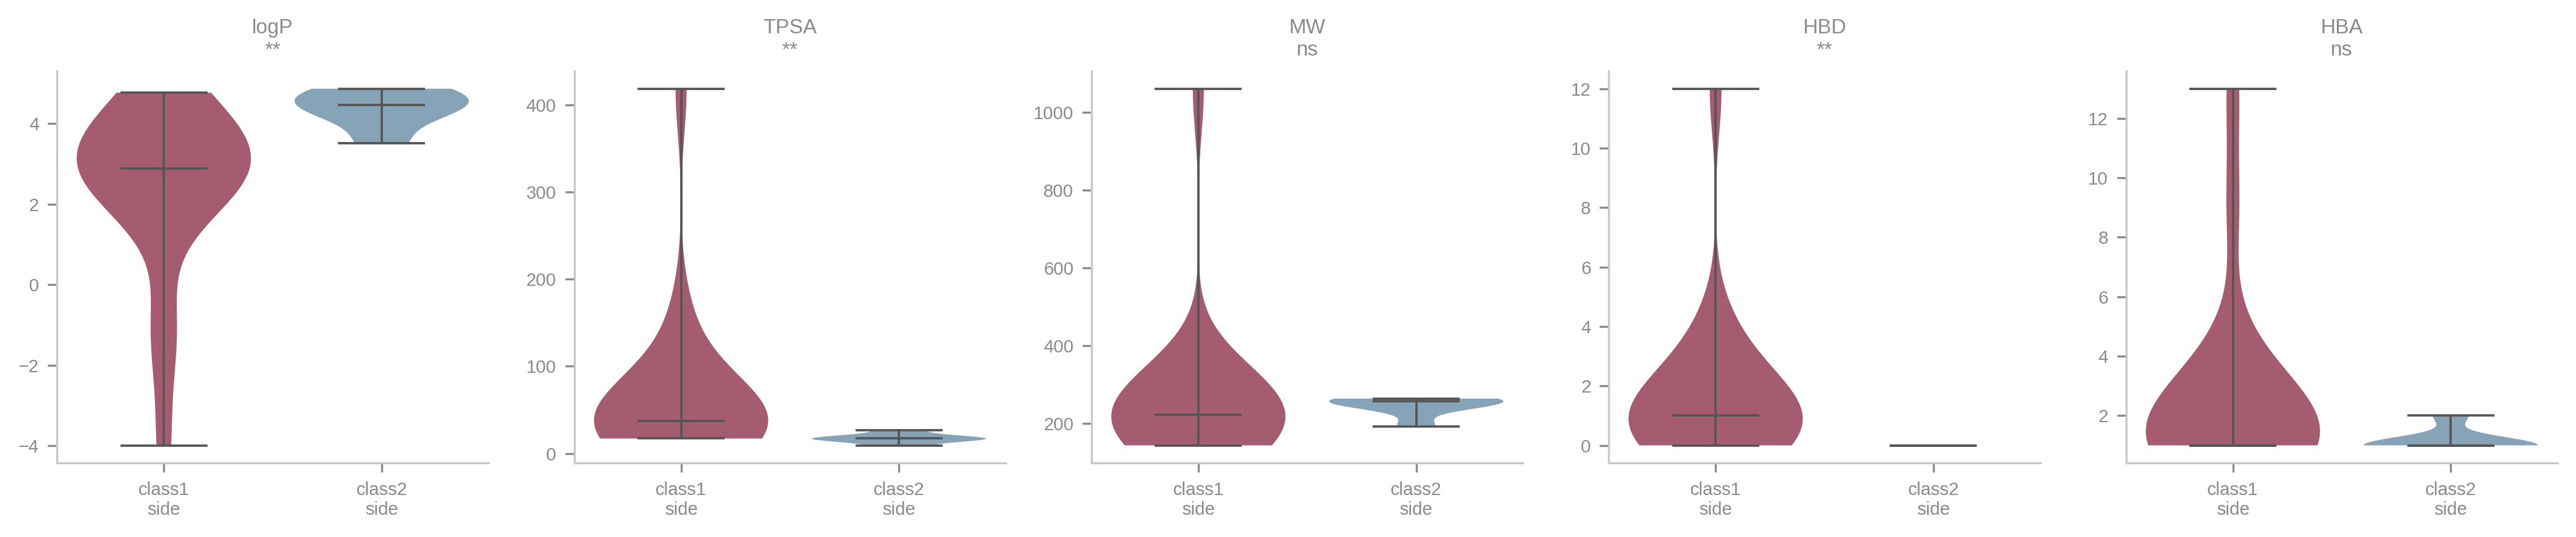

In [6]:
fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.7, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [A[d].dropna().values, B[d].dropna().values]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for pc, c in zip(parts["bodies"], [CLASS1_COL, CLASS2_COL]):
        pc.set_facecolor(c); pc.set_alpha(0.7); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    p = float(res.loc[res.descriptor == d, "p"].iloc[0])
    s = "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"
    ax.set_title(f"{d}\n{s}", fontsize=8)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["class1\nside", "class2\nside"], fontsize=7)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "02_side_descriptors"); plt.show()

## Functional groups in the two sides

          group  class1_side_%  class2_side_%        p
carboxylic_acid           52.6            0.0 0.050791
  aromatic_ring           36.8           66.7 0.350000
         alkene           31.6           16.7 0.637154
          ether           21.1           33.3 0.606053
         phenol           15.8            0.0 0.553913
          amine           15.8            0.0 0.553913
        alcohol           15.8            0.0 0.553913
       aldehyde           10.5            0.0 1.000000
         ketone           10.5           66.7 0.015133
          ester            5.3           16.7 0.430000
          amide            5.3            0.0 1.000000
        nitrile            0.0            0.0 1.000000


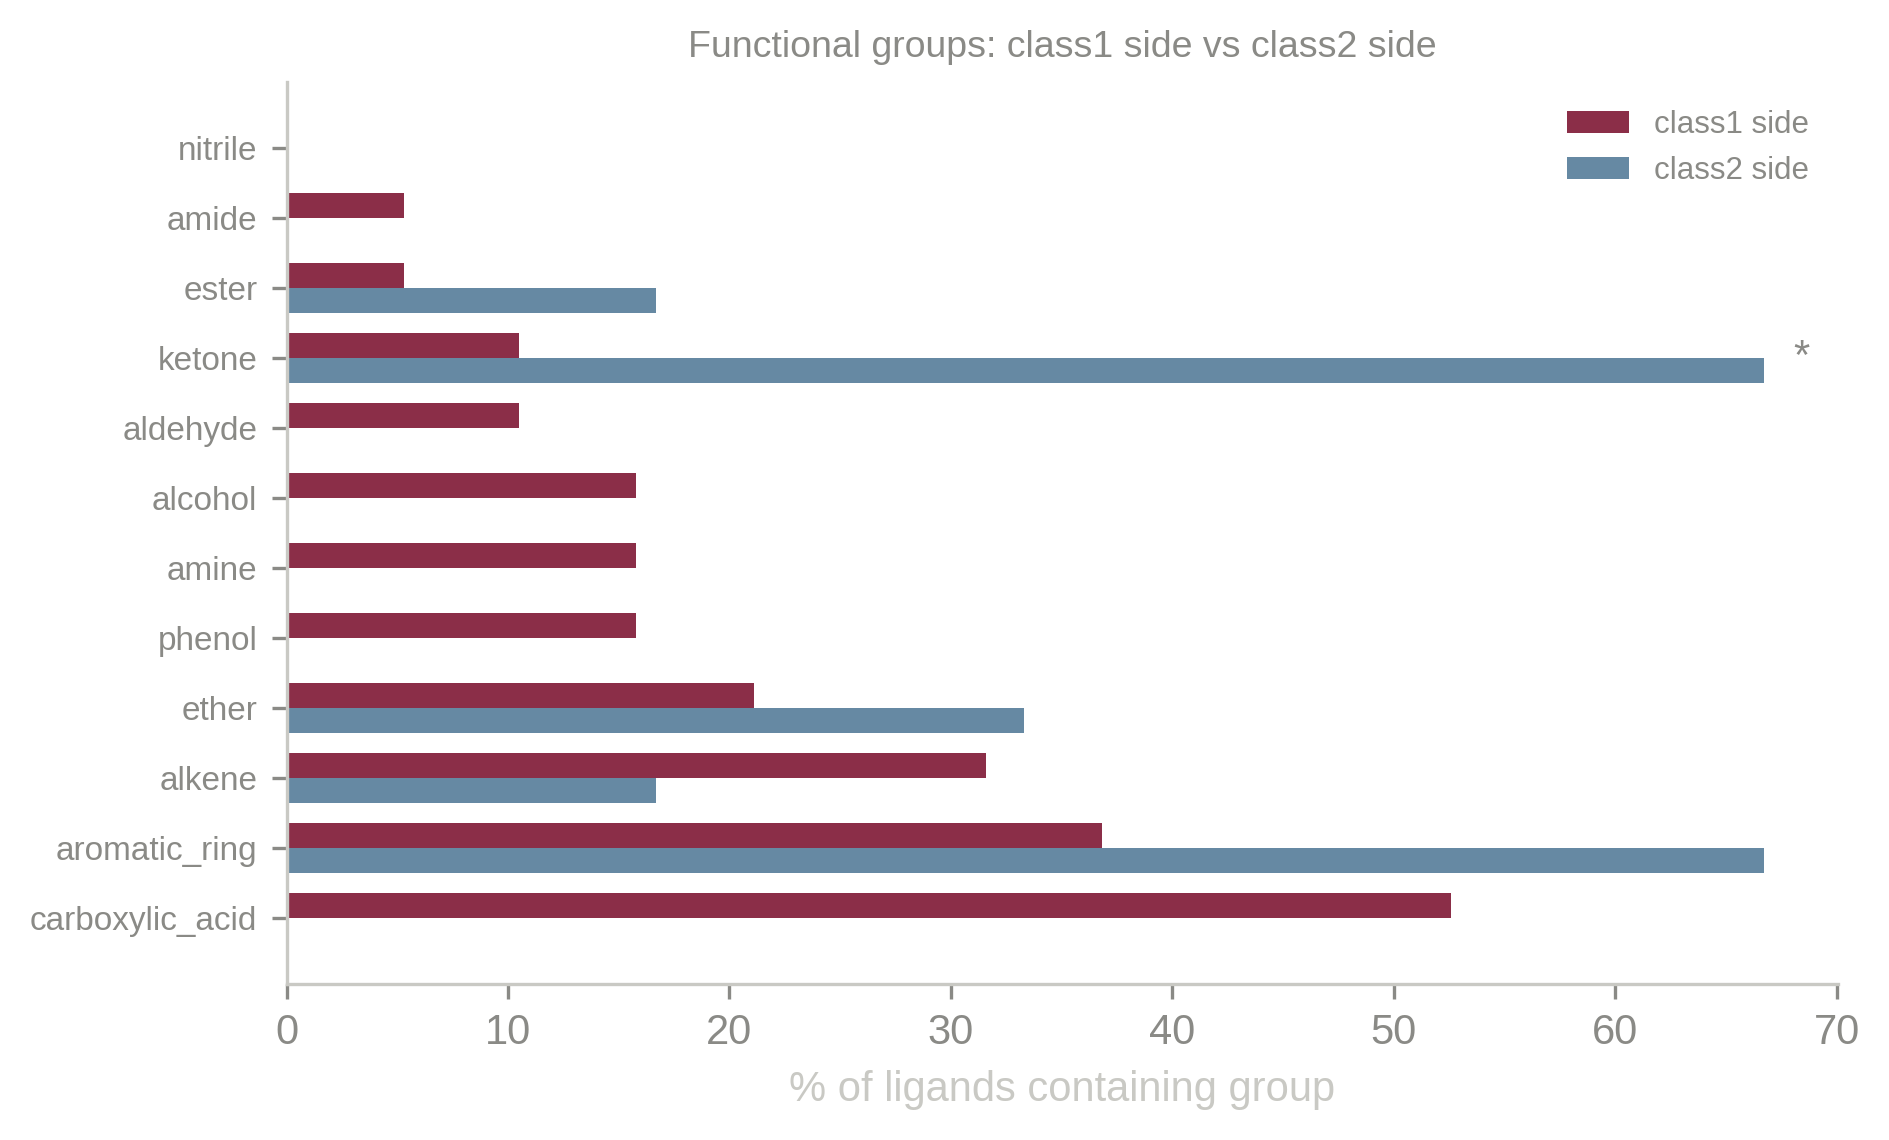

In [7]:
rows = []
for fg in FG_COLS:
    a, b = A[fg], B[fg]
    p = fisher_exact([[int(a.sum()), len(a) - int(a.sum())],
                      [int(b.sum()), len(b) - int(b.sum())]])[1]
    rows.append({"group": fg, "class1_side_%": round(100 * a.mean(), 1),
                 "class2_side_%": round(100 * b.mean(), 1), "p": p})
fg_res = pd.DataFrame(rows).sort_values("class1_side_%", ascending=False)
print(fg_res.to_string(index=False))
save_table(fg_res, "02_side_functional_groups")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.3))
y = np.arange(len(fg_res)); w = 0.36
ax.barh(y + w / 2, fg_res["class1_side_%"], w, color=CLASS1_COL, alpha=0.9, label="class1 side")
ax.barh(y - w / 2, fg_res["class2_side_%"], w, color=CLASS2_COL, alpha=0.9, label="class2 side")
xm = max(fg_res["class1_side_%"].max(), fg_res["class2_side_%"].max())
for yi, p in zip(y, fg_res["p"]):
    if p < 0.05: ax.text(xm * 1.02, yi, "*", va="center", fontsize=10, color="#8a8a86")
ax.set_yticks(y); ax.set_yticklabels(fg_res["group"], fontsize=8)
ax.set_xlabel("% of ligands containing group"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Functional groups: class1 side vs class2 side", fontsize=9)
plt.tight_layout(); save_fig(fig, "02_side_functional_groups"); plt.show()

## Chemistry across the patterns

Kruskal-Wallis across the patterns for the descriptors, then the functional groups that
differ most.

descriptor    H        p    100    011    010
      logP 11.1 0.003941   2.88   4.53   2.13
      TPSA 10.8 0.004405  37.30  17.07  26.30
        MW  2.6 0.273130 251.16 258.40 193.24
       HBD 13.3 0.001275   1.00   0.00   0.00
       HBA  5.1 0.077078   1.00   1.00   2.00


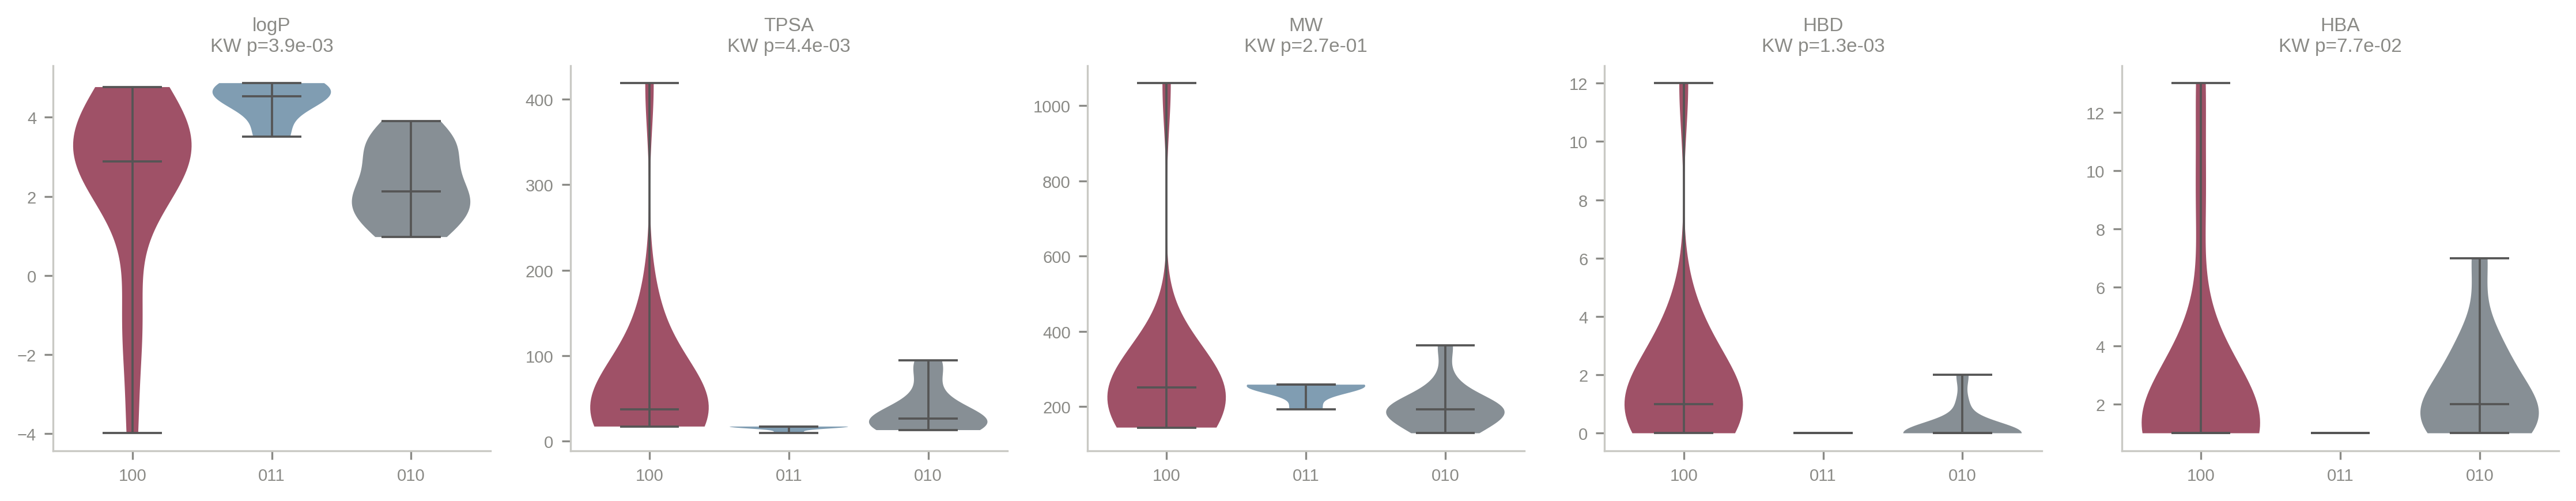

In [8]:
pat_chem = pd.concat([chem[chem.SMILES.isin(anc.pattern_sets[p])].assign(pattern=p)
                      for p in KEEP])

rows = []
for d in DESCRIPTORS:
    data = [pat_chem.loc[pat_chem.pattern == p, d].dropna().values for p in KEEP]
    h, pv = kruskal(*data)
    rows.append({"descriptor": d, "H": round(h, 1), "p": pv,
                 **{p: round(np.median(x), 2) for p, x in zip(KEEP, data)}})
print(pd.DataFrame(rows).to_string(index=False))
save_table(pd.DataFrame(rows), "02_pattern_descriptors")

fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.75, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [pat_chem.loc[pat_chem.pattern == p, d].dropna().values for p in KEEP]
    parts = ax.violinplot(data, showmedians=True, widths=0.85)
    for pc, p in zip(parts["bodies"], KEEP):
        pc.set_facecolor(PAT_COL[p]); pc.set_alpha(0.75); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    pv = float([r["p"] for r in rows if r["descriptor"] == d][0])
    ax.set_title(f"{d}\nKW p={pv:.1e}", fontsize=8)
    ax.set_xticks(range(1, len(KEEP) + 1)); ax.set_xticklabels(KEEP, fontsize=7)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "02_pattern_descriptors"); plt.show()

                  100   011   010  spread
ketone           11.8  80.0  33.3    68.2
carboxylic_acid  58.8   0.0   0.0    58.8
aromatic_ring    29.4  80.0  58.3    50.6
alkene           23.5  20.0  66.7    46.7
ether            11.8  20.0  58.3    46.6
ester             0.0   0.0  33.3    33.3
amine            17.6   0.0   0.0    17.6
alcohol          17.6   0.0   8.3    17.6
aldehyde         11.8   0.0   8.3    11.8
phenol           11.8   0.0   0.0    11.8
amide             5.9   0.0   8.3     8.3
nitrile           0.0   0.0   0.0     0.0


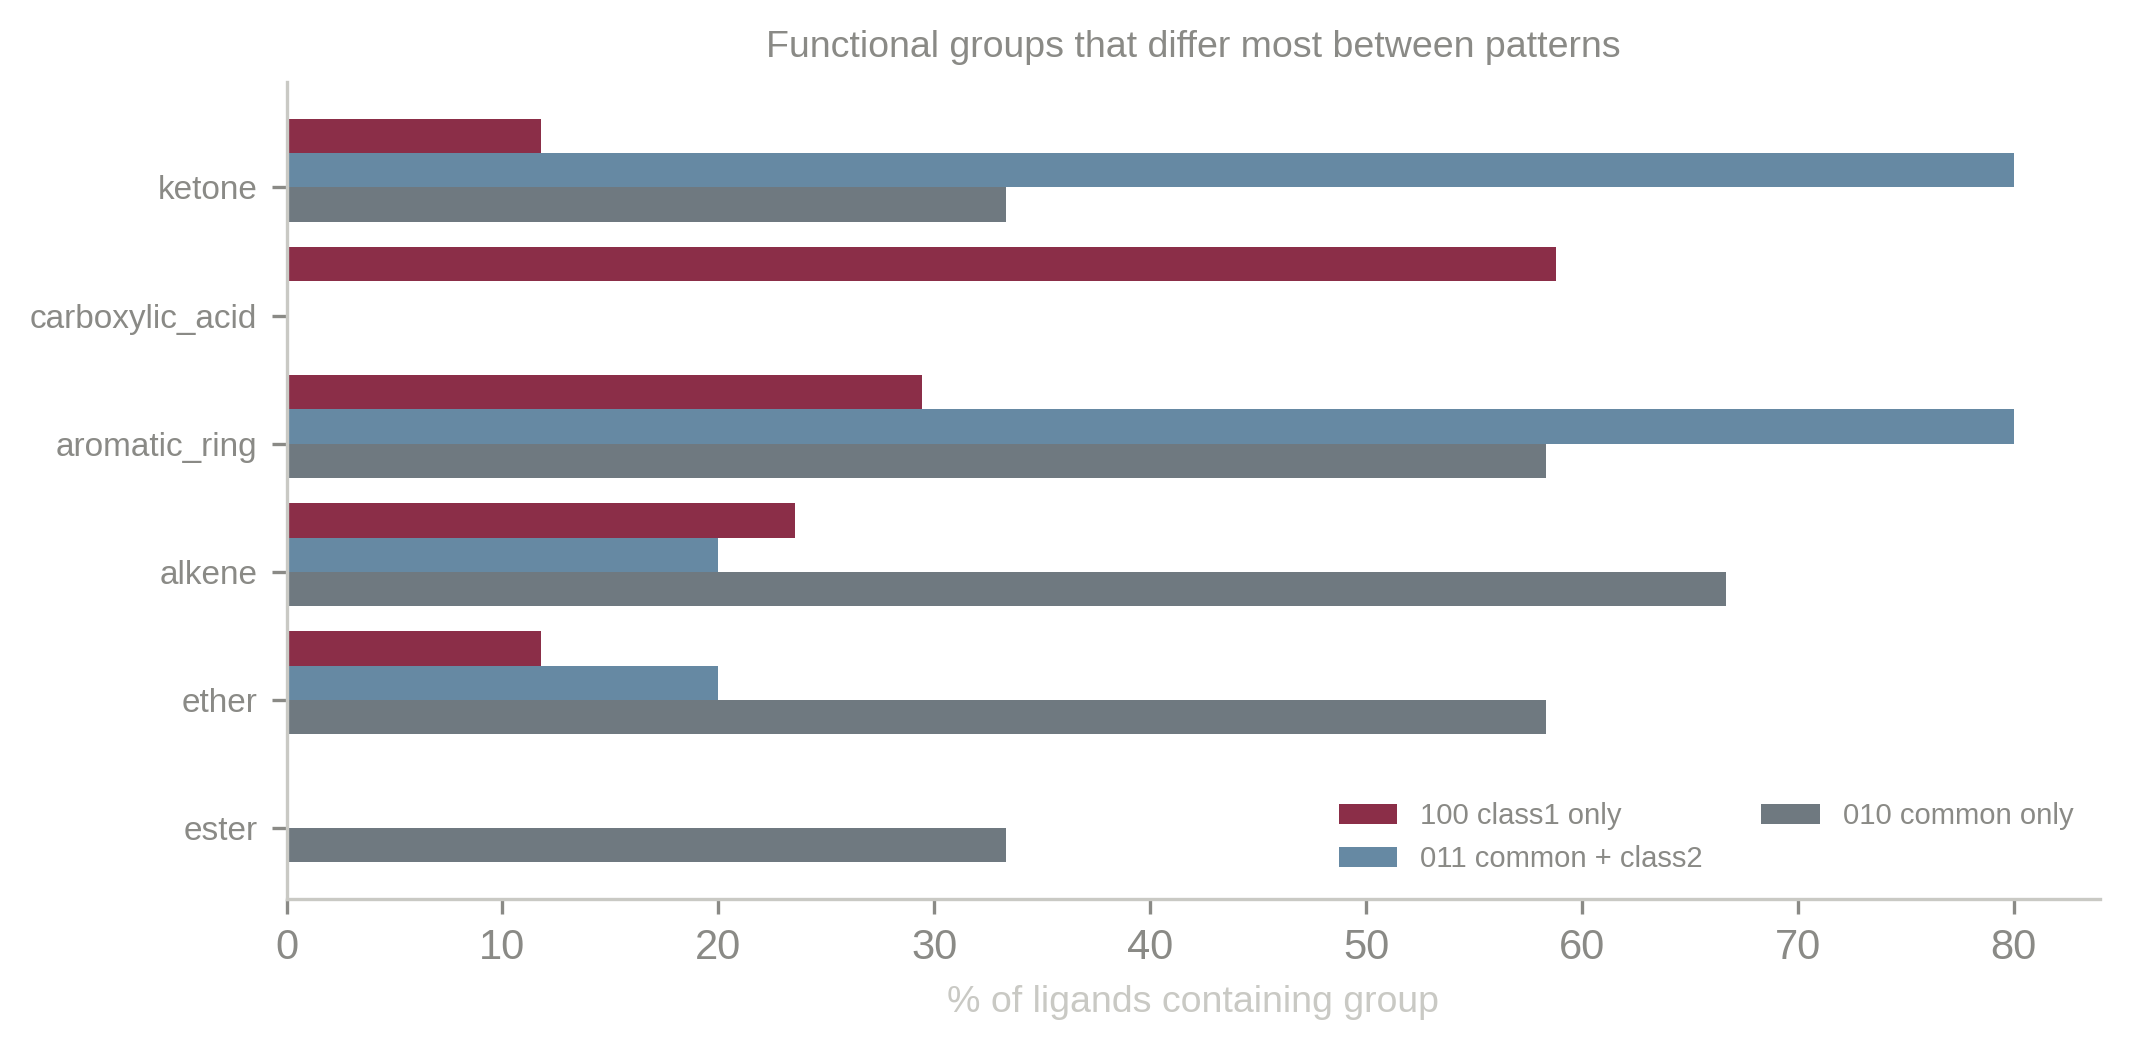

In [9]:
fg_pat = pd.DataFrame({p: chem[chem.SMILES.isin(anc.pattern_sets[p])][FG_COLS].mean() * 100
                       for p in KEEP})
fg_pat["spread"] = fg_pat.max(axis=1) - fg_pat.min(axis=1)
fg_pat = fg_pat.sort_values("spread", ascending=False)
print(fg_pat.round(1).to_string())
save_table(fg_pat.reset_index().rename(columns={"index": "functional_group"}),
           "02_pattern_functional_groups")

show = fg_pat.drop(columns="spread").head(6)
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
y = np.arange(len(show)); w = 0.8 / len(KEEP)
for i, p in enumerate(KEEP):
    ax.barh(y + (i - len(KEEP) / 2) * w, show[p], w, color=PAT_COL[p], alpha=0.9,
            label=f"{p} {PATTERN_LABELS[p]}")
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("% of ligands containing group", fontsize=9)
ax.legend(frameon=False, fontsize=7, ncol=2)
ax.set_title("Functional groups that differ most between patterns", fontsize=9)
plt.tight_layout(); save_fig(fig, "02_pattern_functional_groups"); plt.show()